# Import and load

In [76]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  
# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd 
# Provides tools for creating and manipulating data structures. 
import re
# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  
# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  
# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  
# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  
# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  
# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  
# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  
# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  
# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  
# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  
# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  
# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  
# Offers utilities for generating random numbers and sequences.
import random  
# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

In [77]:
data_train = pd.read_csv("data/train.csv")  # Loads the training dataset from a CSV file into a Pandas DataFrame.
data_test = pd.read_csv("data/test.csv")    # Loads the testing dataset from a CSV file into a Pandas DataFrame.

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


# Data description and manipulation summary

| **Feature**                   | **Description**                                                                                 | **Data Type**  | **Nullability** | **Cast/Re-elaboration Needed**    |
|-------------------------------|-------------------------------------------------------------------------------------------------|----------------|-----------------|----------------------------------|
| **originalTitle**             | Original title, in the original language.                                                      | String         | Non-Null        | Cast all to lowecase strings with no special character     |
| **runtimeMinutes**            | Primary runtime of the title, in minutes.                                                     | Integer        | -               | -1 if NA                          |
| **isAdult**                   | Whether or not the title is for adults (0: non-adult; 1: adult).                              | Boolean        | -               | Bool                              |
| **startYear**                 | Release year of a title; for TV Series, the series start year.                                | Integer        | -               | -                                 |
| **endYear**                   | TV Series end year.                                                                           | Integer        | -               | -1 if NA                          |
| **numVotes**                  | Number of votes the title has received.                                                       | Integer        | -               | -                                 |
| **numRegions**                | Number of regions for this version of the title.                                              | Integer        | -               | -                                 |
| **worstRating**               | Worst title rating.                                                                           | Integer        | -               | -                                 |
| **bestRating**                | Best title rating.                                                                            | Integer        | -               | -                                 |
| **canHaveEpisodes**           | Whether or not the title can have episodes.                                                   | Boolean        | -               | -                                 |
| **isRatable**                 | Whether or not the title can be rated by users.                                               | Boolean        | -               | -                                 |
| **totalImages**               | Total number of images for the title on the IMDb page.                                        | Integer        | -               | -                                 |
| **totalVideos**               | Total number of videos for the title on the IMDb page.                                        | Integer        | -               | -                                 |
| **totalCredits**              | Total number of credits for the title.                                                        | Integer        | -               | -                                 |
| **criticReviewsTotal**        | Total number of critic reviews.                                                               | Integer        | -               | -                                 |
| **awardWins**                 | Number of awards the title won.                                                               | Integer        | -               | -1 if false                       |
| **awardNominationsExcludeWins** | Number of award nominations excluding wins.                                                   | Integer        | -               | -                                 |
| **titleType**                 | Type/format of the title (e.g., movie, short, tvseries, tvepisode, video, etc.).              | String         | -               | Merging                           |
| **rating**                    | IMDb title rating class.                                                                      | Object        | -               | cast to an int mantaining the upper bound                       |
| **ratingCount**               | Total number of user ratings submitted for the title.                                         | Integer        | -               | -                                 |
| **countryOfOrigin**           | Country where the title was primarily produced.                                               | One Hot Encoded | -              | One hot encoding                  |
| **genres**                    | Genre(s) associated with the title (e.g., drama, comedy, action).                            | One Hot Encoded | -              | One hot encoding                  |
| **userReviewsTotal**          | Total number of user reviews.                                                                 | Integer        | -               | -                                 |

# Missing values analysis
Now we will analyze the missing values in the dataset.

In order to achieve that first of all, analyzing the dataset we see that a missing values in the origina dataset is '\N'.

The following function prints a plot of percentage of missing values of each column of the dataset.
The percentage of the missing values is coloured by his components grouped by "titleType"

/tmp/ipykernel_4449/1475037635.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType', group_keys=False).apply(
/tmp/ipykernel_4449/1475037635.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))
/tmp/ipykernel_4449/1475037635.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping colu

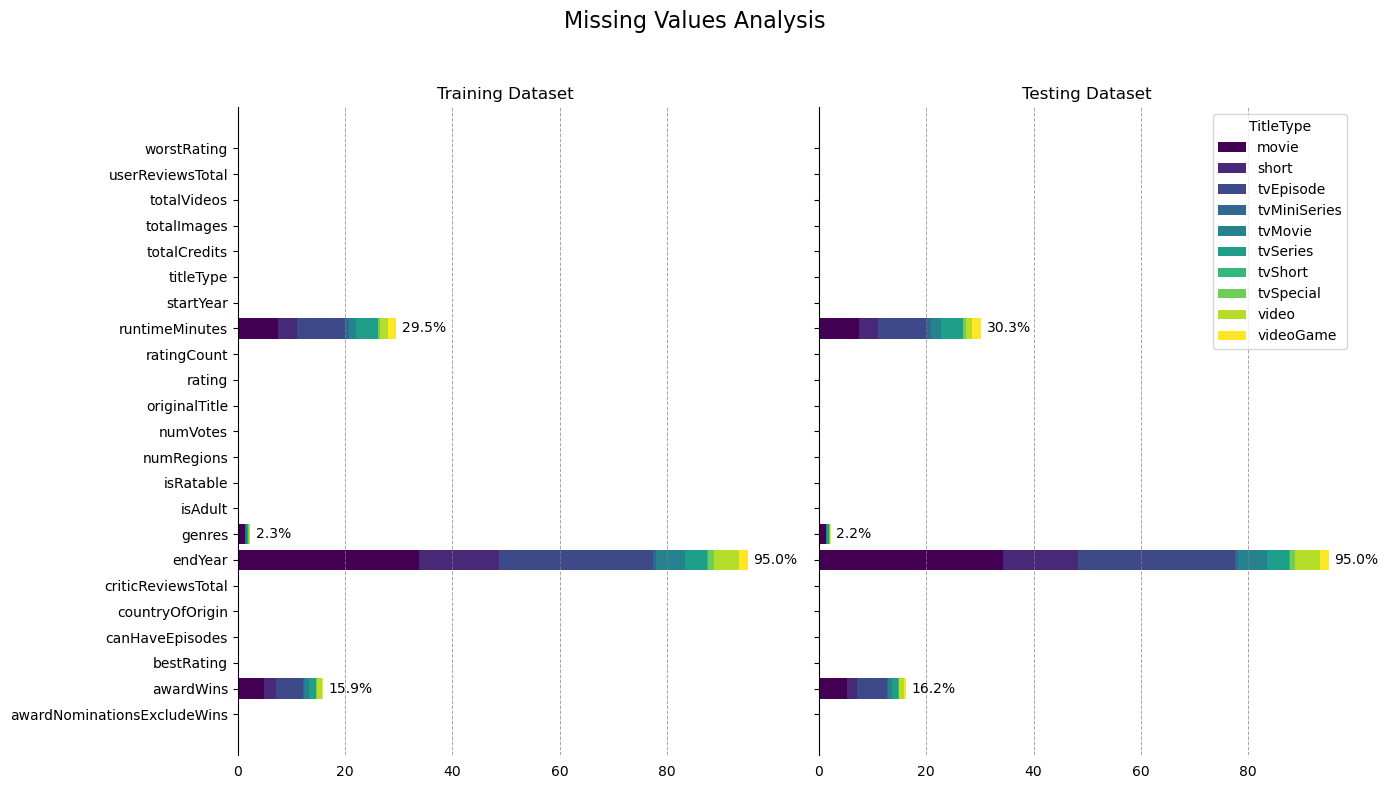

In [78]:
def plot_missing_values_by_title_type_combined(data_train, data_test, global_title, train_title, test_title):
    """
    Plots the percentage of missing values for each column in both datasets (train and test),
    grouped by titleType, with customizable titles for the figure and subplots.

    Args:
        data_train (pd.DataFrame): The training dataset containing various columns including 'titleType'.
        data_test (pd.DataFrame): The testing dataset containing various columns including 'titleType'.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def plot_individual(ax, data, title, show_legend=False):
        """
        Helper function to create a plot for an individual dataset.
        """
        # Replace '\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Calculate the overall percentage of missing values for each column
        overall_missing_percentages = data.isna().mean() * 100

        # Sort columns alphabetically
        overall_missing_percentages = overall_missing_percentages.sort_index()

        # Calculate the percentage of missing values for each column grouped by titleType
        grouped_missing = data.groupby('titleType', group_keys=False).apply(
            lambda x: x.isna().sum() / len(data) * 100
        )

        # Sort columns alphabetically in grouped data
        grouped_missing = grouped_missing[overall_missing_percentages.index]

        left = np.zeros(len(overall_missing_percentages))

        # Get the viridis colormap
        colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))

        # Alternate background shading for rows
        for i in range(len(overall_missing_percentages)):
            ax.barh(
                y=[i],
                width=0,  # Invisible bar for background
                height=0.9,  # Adjust for full coverage
                color='gray' if i % 2 == 0 else 'white',
                edgecolor='none'
            )

        for i, titleType in enumerate(grouped_missing.index.get_level_values(0).unique()):
            values = grouped_missing.loc[titleType]
            bars = ax.barh(overall_missing_percentages.index, values, left=left, label=titleType, color=colormap(i))
            left += values

        # Add percentage labels to the overall missing values
        for i, (column, percentage) in enumerate(overall_missing_percentages.items()):
            if percentage > 0:  # Only add text if the percentage is greater than 0
                ax.text(
                    overall_missing_percentages[column] + 1,  # Position the text slightly after the bar
                    i,
                    f'{percentage:.1f}%',
                    va='center',
                    ha='left',
                    fontsize=10,
                    color='black'
                )

        # Remove the top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Add dashed gridlines for the x-axis numbers
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Set subplot-specific title
        ax.set_title(title)

        # Adjust the y-axis tick labels rotation and alignment
        ax.set_yticks(range(len(overall_missing_percentages.index)))
        ax.set_yticklabels(overall_missing_percentages.index, rotation=0, ha='right')

        # Show legend only if specified
        if show_legend:
            ax.legend(title='TitleType', loc='upper right', bbox_to_anchor=(1, 1))

    # Create a shared figure for both datasets
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=2, 
        figsize=(14, 8), 
        sharey=True, 
        gridspec_kw={'width_ratios': [0.8, 0.8]}  # Adjust widths of the subplots
    )

    # Plot for training data
    plot_individual(axes[0], data_train, train_title, show_legend=False)

    # Plot for testing data
    plot_individual(axes[1], data_test, test_title, show_legend=True)

    # Add a common title
    fig.suptitle(global_title, fontsize=16)

    # Adjust layout to include the global title and space for the legend
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage
plot_missing_values_by_title_type_combined(
    data_train=data_train,
    data_test=data_test,
    global_title="Missing Values Analysis",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)


# `rating`
The rating column is formatted as `(x, x+1]`, where `x` represents the lower bound, and `x+1` is the upper bound.

To simplify analysis and standardize the data format, the range is converted into a single value by retaining only the upper bound (x+1) as an integer.

In [79]:
data_train['rating'] = data_train['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))
data_test['rating'] = data_test['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))

print("rating cleaned successfully.")

rating cleaned successfully.


#### `startYear` and `endYear`

`endYear` has missing values.
The following code snippet shows the percentage of missing values grouped by `titleType`.

/tmp/ipykernel_4449/2897432378.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(
/tmp/ipykernel_4449/2897432378.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


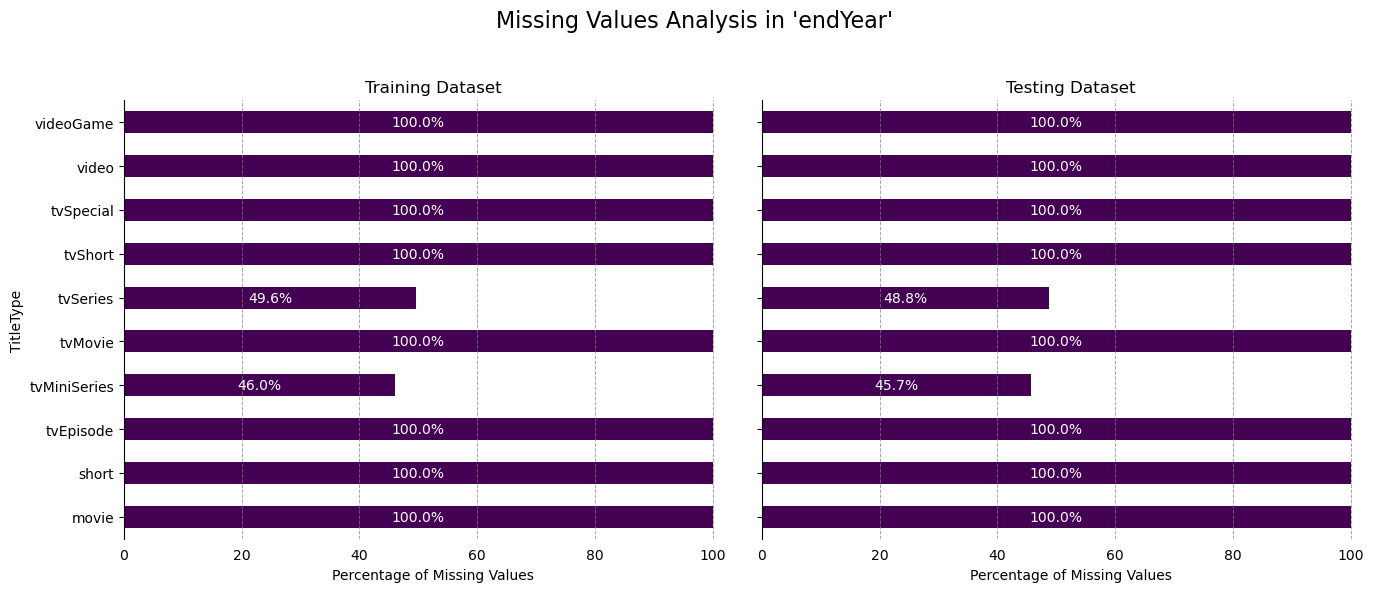

In [80]:
def analyze_missing_years_combined(data_train, data_test, global_title, train_title, test_title):
    """
    Analyze missing values in the 'endYear' column for both training and testing datasets and display
    the percentage of missing values grouped by 'titleType' in a combined plot.

    Args:
        data_train (pd.DataFrame): The training dataset containing 'endYear' and 'titleType' columns.
        data_test (pd.DataFrame): The testing dataset containing 'endYear' and 'titleType' columns.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def plot_individual(ax, data, title):
        """
        Helper function to plot missing values for an individual dataset.
        """
        # Replace '\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Calculate the percentage of missing values for each 'titleType'
        grouped_missing = data.groupby('titleType').apply(
            lambda x: x['endYear'].isna().mean() * 100
        )
        grouped_missing = grouped_missing.sort_index()  # Sort by index (alphabetical order)

        # Plot the data
        grouped_missing.plot(kind='barh', ax=ax, colormap='viridis')
        ax.set_title(title)
        ax.set_xlabel('Percentage of Missing Values')
        ax.set_ylabel('TitleType')

        # Add dashed gridlines parallel to the y-axis
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Remove the top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Add percentage labels to the bars
        for p in ax.patches:
            width = p.get_width()
            if width > 0:  # Only add text if the width is greater than 0
                ax.annotate(f'{width:.1f}%', 
                            (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2), 
                            ha='center', va='center', fontsize=10, color='white')

    # Create a shared figure for both datasets
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

    # Plot for training data
    plot_individual(axes[0], data_train, train_title)

    # Plot for testing data
    plot_individual(axes[1], data_test, test_title)

    # Add a common title
    fig.suptitle(global_title, fontsize=16)

    # Adjust layout for better visualization
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage
analyze_missing_years_combined(
    data_train=data_train,
    data_test=data_test,
    global_title="Missing Values Analysis in 'endYear'",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)


So the `endYear` is just for `tvMiniSeries` and `tvSeries`. The snippet that follows prints a list of `startYear` if `endYear` is missing ordered and without repetition. For each group print also the cardinality of the set.


/tmp/ipykernel_4449/856332810.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('viridis', len(combined_df.columns))


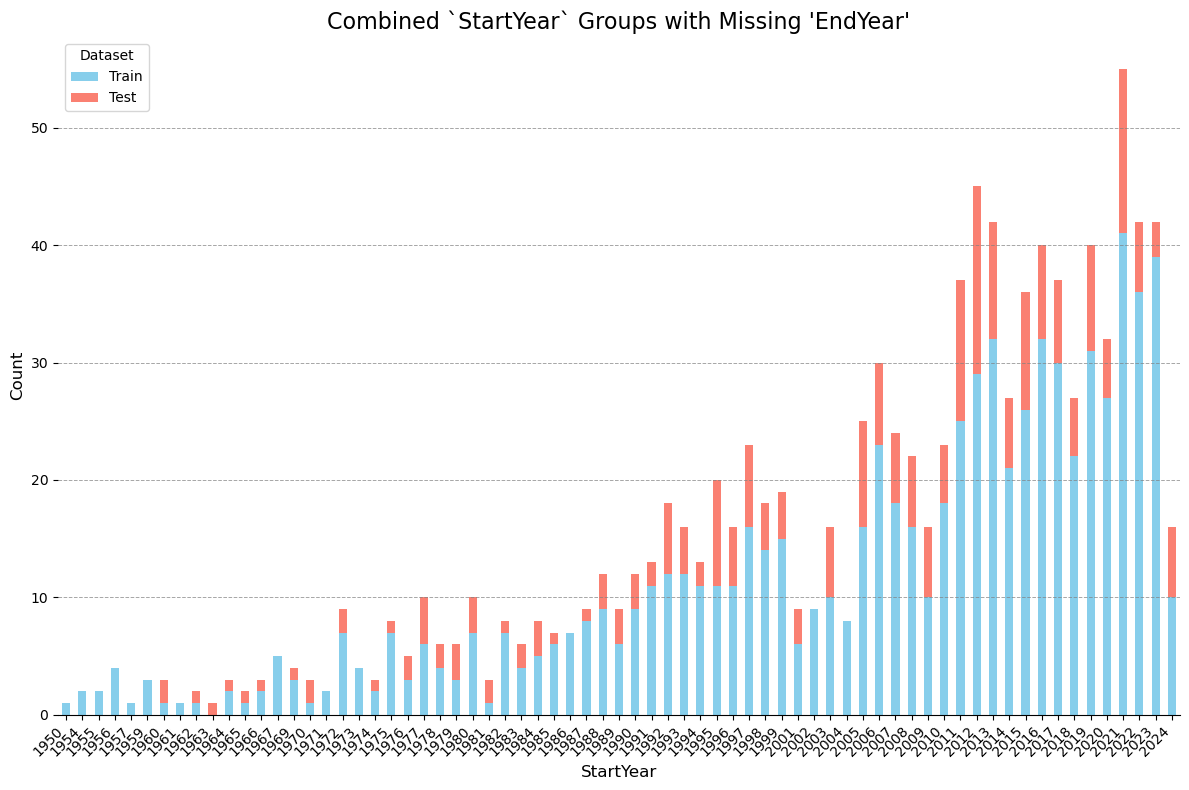

In [81]:
def explore_end_year_behavior_combined(data_train, data_test):
    """
    Combines and visualizes the cardinality of 'startYear' groups where 'endYear' is missing
    for 'tvSeries' and 'tvMiniSeries' in both training and testing datasets.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The testing dataset.
    """
    def process_data(data):
        """
        Processes the data to compute the cardinality of 'startYear' groups where 'endYear' is missing.
        """
        # Replace '\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Convert startYear and endYear to numeric for calculations
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
        data['endYear'] = pd.to_numeric(data['endYear'], errors='coerce')

        # Filter only tvSeries and tvMiniSeries
        filtered_data = data[data['titleType'].isin(['tvSeries', 'tvMiniSeries'])]

        # Calculate the cardinality of the set for each group
        grouped_start_years = filtered_data[filtered_data['endYear'].isna()].groupby('startYear').size()
        return grouped_start_years

    # Process both datasets
    grouped_train = process_data(data_train)
    grouped_test = process_data(data_test)

    # Combine the two datasets into a single DataFrame
    combined_df = pd.DataFrame({
        'Train': grouped_train,
        'Test': grouped_test
    }).fillna(0)

    # Plot the combined data
    fig, ax = plt.subplots(figsize=(12, 8))
    colormap = plt.cm.get_cmap('viridis', len(combined_df.columns))
    combined_df.sort_index().plot(kind='bar', stacked=True, ax=ax, color=['skyblue', 'salmon'])

    # Customization
    ax.set_title("Combined `StartYear` Groups with Missing 'EndYear'", fontsize=16)
    ax.set_xlabel("StartYear", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.legend(title="Dataset")
    ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()

# Example usage
explore_end_year_behavior_combined(data_train, data_test)


There is no clear behaviour for missing values.

It can be assumed that increasng number for most recent year is due the fact that some tvSeries or tvMiniSeries are not finished, but we can't be sure, so we just decided to remove the column.

In [82]:
data_test.drop('endYear', axis=1, inplace=True)
data_train.drop('endYear', axis=1, inplace=True)

# runTimeMinutes
Let's check the percentage of missing values (`\N`) and then, as we did for `startYear` and `endYear` we plot it for cathegories. 

/tmp/ipykernel_4449/2362929088.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(
/tmp/ipykernel_4449/2362929088.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


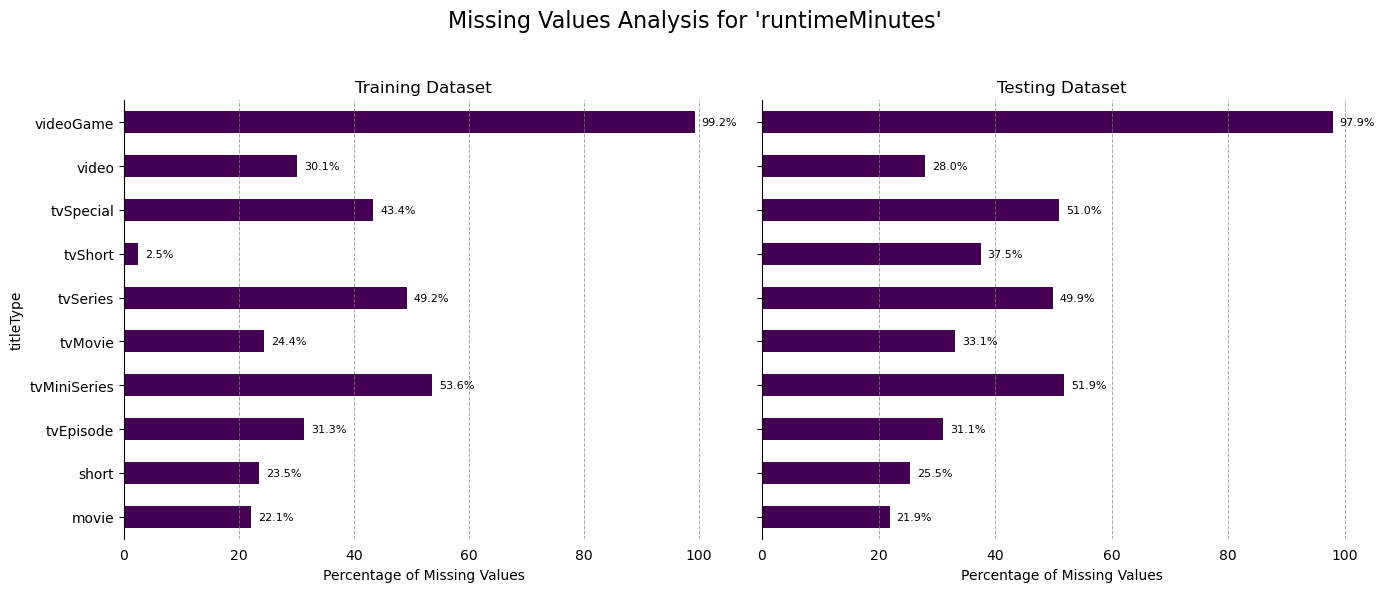

In [83]:
def analyze_missing_values_combined(data_train, data_test, column_to_analyze, group_by_column, global_title, train_title, test_title):
    """
    Analyze missing values ('\\N') in a specific column for both training and testing datasets
    and display the percentage of missing values grouped by another column in a combined plot.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The testing dataset.
        column_to_analyze (str): The column to analyze for missing values.
        group_by_column (str): The column to group by when calculating missing values.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def process_and_plot(ax, data, title):
        """
        Helper function to process data and plot missing value analysis for a single dataset.
        """
        # Replace '\\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Ensure the columns exist in the dataset
        if column_to_analyze not in data.columns:
            raise ValueError(f"Column '{column_to_analyze}' not found in the dataset.")
        if group_by_column not in data.columns:
            raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

        # Calculate the percentage of missing values for the specified column grouped by the group_by_column
        grouped_missing = data.groupby(group_by_column).apply(
            lambda x: x[column_to_analyze].isna().mean() * 100
        )
        grouped_missing = grouped_missing.sort_index()

        # Plot the data
        grouped_missing.plot(kind='barh', ax=ax, colormap="viridis")
        ax.set_title(title)
        ax.set_xlabel('Percentage of Missing Values')
        ax.set_ylabel(group_by_column)

        # Add dashed gridlines parallel to the x-axis
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Remove spines: keep the left spine, remove the bottom, top, and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(True)

        # Add percentage labels to the bars
        for p in ax.patches:
            if p.get_width() > 0:  # Only annotate non-zero bars
                ax.annotate(f'{p.get_width():.1f}%', 
                            (p.get_width(), p.get_y() + p.get_height() / 2.), 
                            ha='left', va='center', fontsize=8, color='black', xytext=(5, 0),
                            textcoords='offset points')

    # Create a shared figure for both datasets
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

    # Plot for training data
    process_and_plot(axes[0], data_train, train_title)

    # Plot for testing data
    process_and_plot(axes[1], data_test, test_title)

    # Add a common title
    fig.suptitle(global_title, fontsize=16)

    # Adjust layout for better visualization
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage
analyze_missing_values_combined(
    data_train=data_train,
    data_test=data_test,
    column_to_analyze='runtimeMinutes',
    group_by_column='titleType',
    global_title="Missing Values Analysis for 'runtimeMinutes'",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)


## Drop `videoGame`
Due the fact that videoGame is a cathegory which is different from all the other and has a lot of missing value we drop it also because his cardinality is low.


In [84]:
# Drop rows where titleType is 'videoGame'
data_train = data_train[data_train['titleType'] != 'videoGame']
data_test = data_test[data_test['titleType'] != 'videoGame']

print("Rows with 'videoGame' titleType dropped successfully.")

Rows with 'videoGame' titleType dropped successfully.


# awardWins
As before we check for missing values

/tmp/ipykernel_4449/2362929088.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(
/tmp/ipykernel_4449/2362929088.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


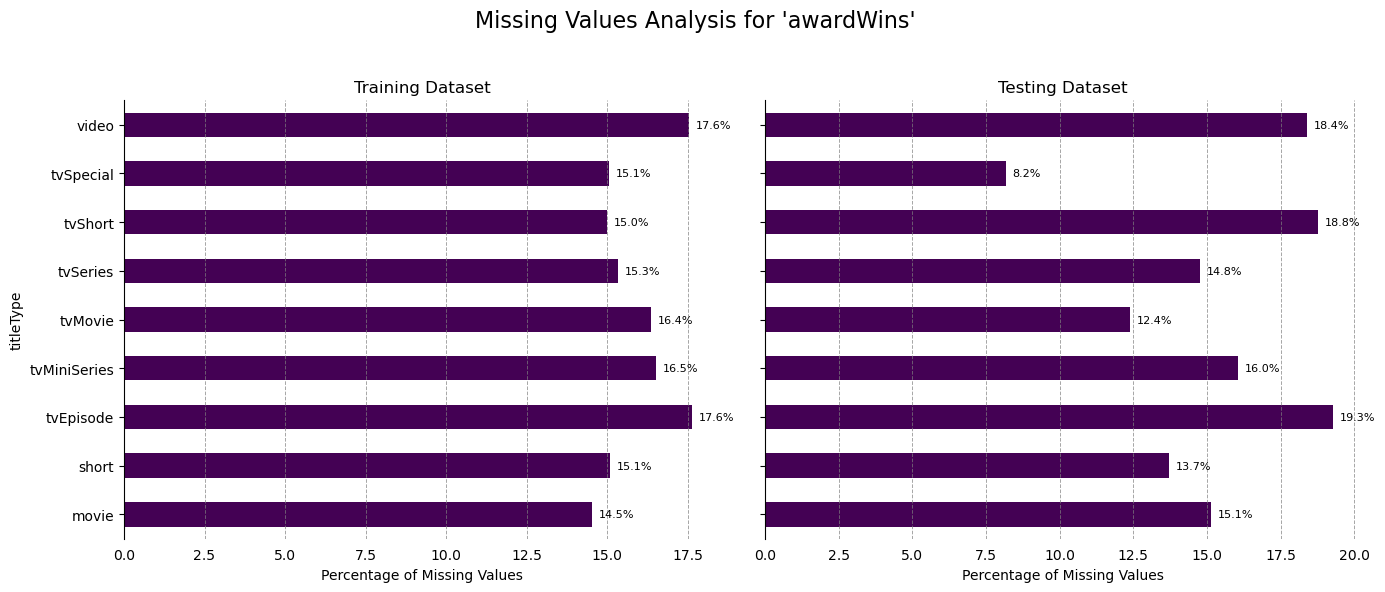

In [85]:
analyze_missing_values_combined(
    data_train=data_train,
    data_test=data_test,
    column_to_analyze='awardWins',
    group_by_column='titleType',
    global_title="Missing Values Analysis for 'awardWins'",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)

In this case we check for each group the median of `awardWins`

In [86]:

def print_group_median(data, column_to_analyze, group_by_column):
    """
    Print the median of a specific column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing various columns.
        column_to_analyze (str): The column to calculate the median for.
        group_by_column (str): The column to group by when calculating the median.
    """
    # Ensure the columns exist in the dataset
    if column_to_analyze not in data.columns:
        raise ValueError(f"Column '{column_to_analyze}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Convert the column to analyze to numeric (if not already)
    data[column_to_analyze] = pd.to_numeric(data[column_to_analyze], errors='coerce')

    # Calculate the median grouped by the group_by_column
    grouped_median = data.groupby(group_by_column)[column_to_analyze].median()

    # Print the results
    print(f"Median values of '{column_to_analyze}' grouped by '{group_by_column}':")
    print(grouped_median)

print_group_median(data_train, 'awardWins', 'titleType')
print_group_median(data_test, 'awardWins', 'titleType')


Median values of 'awardWins' grouped by 'titleType':
titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64
Median values of 'awardWins' grouped by 'titleType':
titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64


In [87]:
def fill_missing_values_with_median(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specified column with the median value of the column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing the column to fill and the group-by column.
        column_to_fill (str): The column in which to fill missing values.
        group_by_column (str): The column to group by when calculating the median.

    Returns:
        pd.DataFrame: A DataFrame with missing values in the specified column filled.
    """
    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Replace '\N' with NaN for proper handling of missing values
    data[column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')  # Ensure numeric type
    data[group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string

    # Fill missing values with the median of the group
    data[column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    return data

# Example usage
data_train = fill_missing_values_with_median(data_train, 'awardWins', 'titleType')
data_test = fill_missing_values_with_median(data_test, 'awardWins', 'titleType')
print("Missing values of `awardWins` filled successfully.")

Missing values of `awardWins` filled successfully.


# `worstRating` and `bestRating`
These are dummy columns, we just drop them

In [88]:
data_test.drop('worstRating', axis=1, inplace=True)
data_train.drop('worstRating', axis=1, inplace=True)

data_test.drop('bestRating', axis=1, inplace=True)
data_train.drop('bestRating', axis=1, inplace=True)

# `titleType`
Plot the number of element in the dataset groupedBy title type and plot the percentage of missing values in another plot always groupedBy title and only of this column

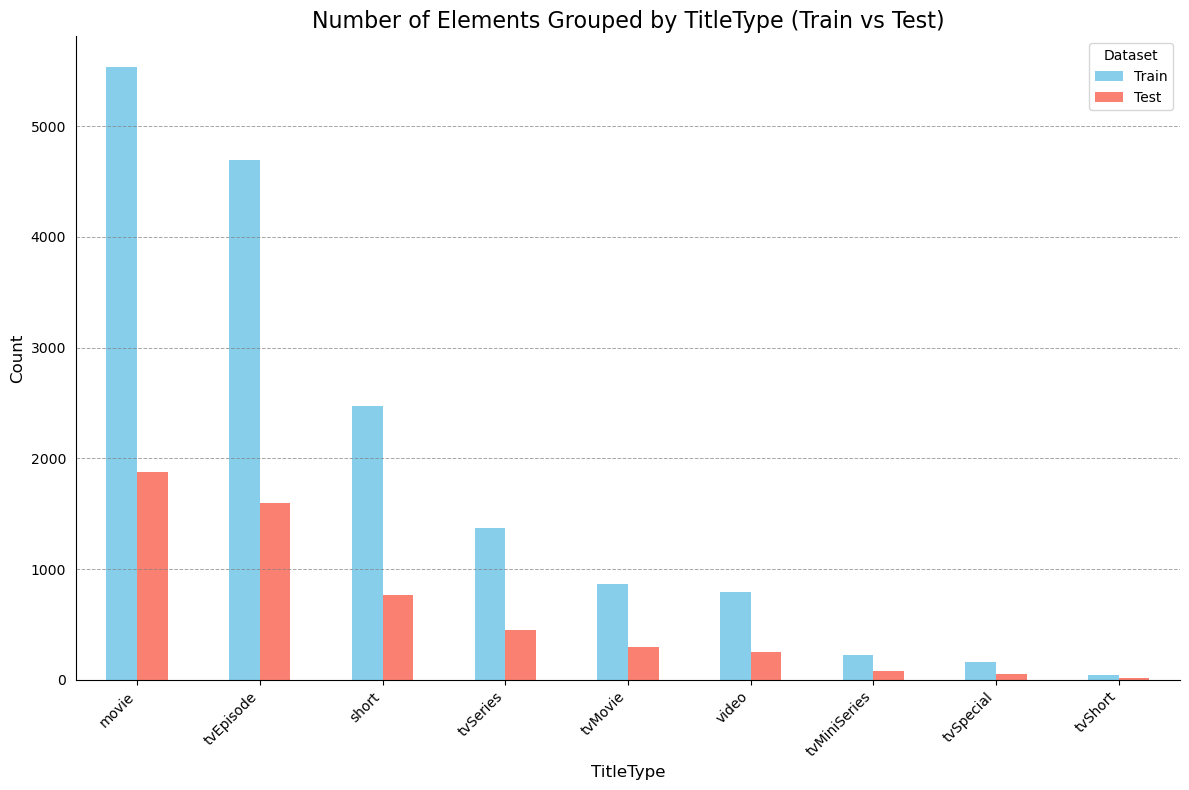

In [89]:
def plot_title_type_analysis_combined(data_train, data_test):
    """
    Plot the number of elements in the training and testing datasets grouped by title type in a single bar chart.
    The bars are sorted by the cardinality of the groups (total count).

    Args:
        data_train (pd.DataFrame): The training dataset containing a 'titleType' column.
        data_test (pd.DataFrame): The testing dataset containing a 'titleType' column.
    """
    # Replace '\\N' with NaN for proper missing value handling
    data_train.replace('\\N', np.nan, inplace=True)
    data_test.replace('\\N', np.nan, inplace=True)

    # Ensure the 'titleType' column exists in both datasets
    if 'titleType' not in data_train.columns or 'titleType' not in data_test.columns:
        raise ValueError("Column 'titleType' not found in one or both datasets.")

    # Count the number of elements grouped by title type for both datasets
    train_counts = data_train['titleType'].value_counts()
    test_counts = data_test['titleType'].value_counts()

    # Combine the counts into a single DataFrame
    combined_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)

    # Add a 'Total' column to sort by total cardinality
    combined_counts['Total'] = combined_counts['Train'] + combined_counts['Test']
    combined_counts = combined_counts.sort_values(by='Total', ascending=False).drop(columns=['Total'])

    # Plot the data
    ax = combined_counts.plot(kind='bar', figsize=(12, 8), color=['skyblue', 'salmon'])

    # Add labels and title
    plt.title('Number of Elements Grouped by TitleType (Train vs Test)', fontsize=16)
    plt.ylabel('Count', fontsize=12)
    plt.xlabel('TitleType', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title="Dataset", fontsize=10)

    # Add gridlines parallel to the y-axis
    ax.yaxis.set_ticks_position('none')  # Remove ticks from the y-axis
    ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

    # Remove spines for a clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# Example usage
plot_title_type_analysis_combined(data_train, data_test)



#### `isRatable`, `canHaveEpisodes` and `isAdult`

- `isRatable` is just removed
- `canHaveEpisode` is mantained
- `isAdult` cast to bool


In [90]:
# Remove `isRatable` column
if 'isRatable' in data_train.columns:
    data_train.drop(columns='isRatable', inplace=True)
if 'isRatable' in data_test.columns:
    data_test.drop(columns='isRatable', inplace=True)

print("Columns refactored successfully.")

Columns refactored successfully.


# `titleType` analysis

1. **Print All Possible Values of `titleType`:**  
   Extract and display all unique values present in the `titleType` column to understand its categories.

2. **Print All Unique Pairs `{titleType, canHaveEpisodes}`:**  
   Display all distinct combinations of `titleType` and `canHaveEpisodes` from the dataset to analyze their relationships.

In [91]:
def analyze_title_types(data):
    # Get and sort unique values of `titleType`
    unique_title_types = sorted(data['titleType'].unique())
    print(unique_title_types)

    # Get and sort unique pairs {titleType, canHaveEpisodes}
    unique_pairs = data[['titleType', 'canHaveEpisodes']].drop_duplicates()
    unique_pairs = unique_pairs.sort_values(by=['titleType', 'canHaveEpisodes'])
    print(unique_pairs)

    return unique_title_types, unique_pairs

# data_train
analyze_title_types(data_train)
analyze_title_types(data_test)

['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video']
        titleType  canHaveEpisodes
2           movie            False
8           short            False
0       tvEpisode            False
7    tvMiniSeries             True
10        tvMovie            False
3        tvSeries             True
287       tvShort            False
11      tvSpecial            False
5           video            False
['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video']
        titleType  canHaveEpisodes
1           movie            False
9           short            False
3       tvEpisode            False
96   tvMiniSeries             True
14        tvMovie            False
6        tvSeries             True
164       tvShort            False
2       tvSpecial            False
0           video            False


(['movie',
  'short',
  'tvEpisode',
  'tvMiniSeries',
  'tvMovie',
  'tvSeries',
  'tvShort',
  'tvSpecial',
  'video'],
         titleType  canHaveEpisodes
 1           movie            False
 9           short            False
 3       tvEpisode            False
 96   tvMiniSeries             True
 14        tvMovie            False
 6        tvSeries             True
 164       tvShort            False
 2       tvSpecial            False
 0           video            False)

There is a correlation between `titleType` and `canHaveEpisodes`. The `canHaveEpisodes` column might be redundant.

In [92]:
# Remove `canHaveEpisodes` column
if 'canHaveEpisodes' in data_train.columns:
    data_train.drop(columns='canHaveEpisodes', inplace=True)
if 'canHaveEpisodes' in data_test.columns:
    data_test.drop(columns='canHaveEpisodes', inplace=True)

# New column `nominations`
1. `Nominations = Award wins + AwardNominations excluded wins` if there is a missing value in one of the original columns, then the values is set to `-1`


In [93]:
def add_nominations_column(data):
    """
    Add a new column `Nominations` computed as:
    Nominations = awardWins + awardNominationsExcludeWins.
    If either value is missing, set `Nominations` to -1.
    
    Parameters:
    - data (pd.DataFrame): The input dataset.
    
    Returns:
    - pd.DataFrame: The updated dataset with the new `Nominations` column.
    """
    
    # Calculate the `Nominations` column
    data['nominations'] = data.apply(
        lambda row: np.nan if row['awardWins'] == -1 or row['awardNominationsExcludeWins'] == -1 
        else row['awardWins'] + row['awardNominationsExcludeWins'], 
        axis=1
    )
    
    return data

data_test = add_nominations_column(data_test)
data_train = add_nominations_column(data_train)

# `originalTitle`
`clean_strings` processes a column by converting it to a lowercase string, removing special characters, and handling lists by concatenating their items into a single string. It ensures that the input is always a string and cleans it to retain only alphanumeric characters and spaces.

This function is applied to the `originalTitle` column of both training (`data_train`) and test (`data_test`) datasets, standardizing the titles for further analysis.

In [94]:
def clean_strings(title):
    # Ensure the value is a string
    if isinstance(title, list):  # Handle lists explicitly
        title = ','.join(title)  # Concatenate list items into a string
    title = str(title)  # Convert to string (if not already)
    # Lowercase the string
    title = title.lower()
    # Remove special characters
    title = re.sub(r'[^a-z0-9\s]', '', title)
    # Return cleaned title
    return title

data_train['originalTitle'].apply(clean_strings)
data_test['originalTitle'].apply(clean_strings)

print("`originalTitle` cleaned successfully.")

`originalTitle` cleaned successfully.


/tmp/ipykernel_4449/1475037635.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType', group_keys=False).apply(
/tmp/ipykernel_4449/1475037635.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))
/tmp/ipykernel_4449/1475037635.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping colu

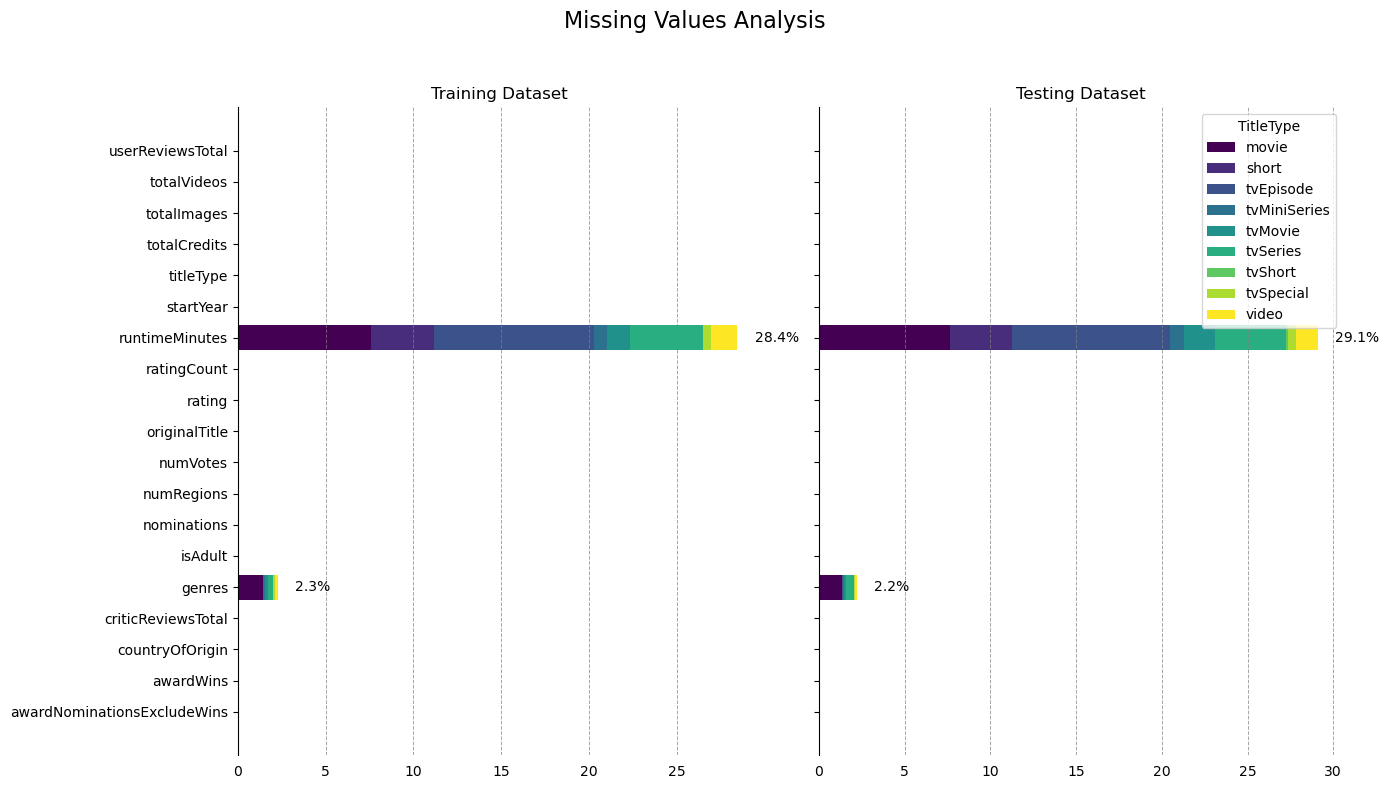

In [95]:
plot_missing_values_by_title_type_combined(
    data_train=data_train,
    data_test=data_test,
    global_title="Missing Values Analysis",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)

# one-hot encoding
This Python code defines a function `process_column` to preprocess a column of a DataFrame by cleaning its values, performing one-hot encoding, and saving metadata about the newly generated columns.

#### Steps in the Function:
1. **Clean the Column**:
   - Ensures the column values are strings.
   - Strips unwanted characters (`[]` and `'`) and splits values into a list.

2. **Add a Count Column**:
   - Creates a new column named dynamically as `NumberOf<ColumnName>`.
   - Stores the count of items in the list for each row.

3. **One-Hot Encoding**:
   - Transforms the column into a one-hot encoded DataFrame by expanding the lists into separate binary columns.

4. **Combine Data**:
   - Merges the one-hot encoded columns back with the original DataFrame.

5. **Save Metadata**:
   - Writes the names of the newly created columns (count column and one-hot encoded columns) to a specified file.

6. **Remove Original Column**:
   - Drops the original column from the DataFrame.

#### `merge_txt_files`
The `merge_txt_files` function merges multiple `.txt` files into a single output file, ensuring no duplicate lines. It reads lines from input files into a set (to remove duplicates), sorts them alphabetically, and writes the result to the specified output file.

- **Removes Duplicates**: Ensures unique lines in the output.
- **Alphabetical Sorting**: Orders lines for consistency.
- **Flexible Input**: Accepts a variable number of input files.


In [96]:
def one_hot_encoding(data, column_name, columns_file, replace_null_with_unknown=False):
    """
    Performs one-hot encoding on a specified column of a DataFrame.

    Args:
        data (pd.DataFrame): Input DataFrame.
        column_name (str): Column to be one-hot encoded.def plot_missing_values_by_title_type_combined(
        data_train = data_train, 
        data_test= data_test, 
        global_title= "missing values",
        train_title =  "train", 
        test_title = "test")
def plot_missing_values_by_title_type_combined(data_train, data_test, global_title, train_title, test_title):
    
        columns_file (str): File to save the new column names.
        replace_null_with_unknown (bool): Replace '\\N' with 'unknown<ColumnName>' if True.

    Returns:
        pd.DataFrame: Updated DataFrame with one-hot encoded columns.
    """
    # Ensure the specified column is a string and clean it
    data[column_name] = data[column_name].astype(str)

    # Replace '\N' with 'unknown<ColumnName>' if specified
    if replace_null_with_unknown:
        unknown_value = f"unknown{column_name.capitalize()}"
        data[column_name] = data[column_name].replace(r"\\N", unknown_value, regex=True)

    # Split the string into a list, cleaning brackets, quotes, and leading/trailing spaces
    data[column_name] = data[column_name].apply(lambda x: [item.strip() for item in x.strip("[]").replace("'", "").split(",")])

    # Add a column for the count of items in the specified column
    number_column_name = f"NumberOf{column_name.capitalize()}"
    data[number_column_name] = data[column_name].apply(len)

    # One-hot encode the specified column
    column_one_hot = pd.get_dummies(data[column_name].apply(pd.Series).stack()).groupby(level=0).sum()

    # Concatenate the one-hot encoded columns with the original dataset
    data = pd.concat([data, column_one_hot], axis=1)

    # Save the names of new columns to a file
    new_columns = list(column_one_hot.columns)
    with open(columns_file, 'w') as f:
        for column in new_columns:
            f.write(f"{column}\n")

    # Remove the original column
    data.drop(columns=[column_name], inplace=True)

    return data




def merge_txt_files(output_file, *input_files):
    merged_lines = set()
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.read().splitlines()
            for line in lines:
                merged_lines.add(line.strip())
    
    with open(output_file, 'w') as f:
        for line in sorted(merged_lines):
            f.write(f"{line}\n")

## One-hot encoding: `countryOfOrigin`

In [97]:
data_train = one_hot_encoding(data_train, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_train.txt')
data_test = one_hot_encoding(data_test, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_test.txt')

merge_txt_files('encoding_lists/countryOfOrigin.txt', 'encoding_lists/countryOfOrigin_train.txt', 'encoding_lists/countryOfOrigin_test.txt')

## One-hot encoding: `genres`

Before to one-hot encode genres we just drop unknown columns ('\N')

In [98]:
# Replace '\N' with NaN for proper handling of missing values
data_train['genres'].replace('\\N', np.nan, inplace=True)
data_test['genres'].replace('\\N', np.nan, inplace=True)

# Drop rows where 'genres' is NaN
data_train.dropna(subset=['genres'], inplace=True)
data_test.dropna(subset=['genres'], inplace=True)

print("Unknown columns dropped successfully.")

Unknown columns dropped successfully.


/tmp/ipykernel_4449/3899060788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['genres'].replace('\\N', np.nan, inplace=True)
/tmp/ipykernel_4449/3899060788.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [99]:
data_train = one_hot_encoding(data_train, 'genres', columns_file='encoding_lists/genres_train.txt', replace_null_with_unknown=False)
data_test = one_hot_encoding(data_test, 'genres', columns_file='encoding_lists/genres_test.txt', replace_null_with_unknown=False)

merge_txt_files('encoding_lists/genres.txt', 'encoding_lists/genres_train.txt', 'encoding_lists/genres_test.txt')


# `title` analysis
Analyzing by eyes the dataset we saw a lot of titles with `episode` or something similar, so we decided to analyze them a little bit to explore their caratheristics.

1. Check most freqent $k$-grams ($k=4$ and $k=5$)
2. Print them


In [100]:
from collections import Counter

def analyze_k_grams(data, column_name='title', k=4, top_n=10):
    # Generate k-grams
    k_grams = []
    for title in data[column_name]:
        k_grams.extend(title[i:i + k] for i in range(len(title) - k + 1))
    
    # Count k-grams frequencies
    k_grams_counter = Counter(k_grams)

    return k_grams_counter

#### K-grams `data_train`, k=5

In [101]:
analyze_k_grams(data_train, column_name='originalTitle', k=5, top_n=10)

Counter({' the ': 1071,
         'pisod': 517,
         'isode': 515,
         'Episo': 512,
         'sode ': 511,
         'ode #': 466,
         ' and ': 409,
         'de #1': 306,
         'e #1.': 283,
         'f the': 281,
         ' of t': 274,
         'of th': 274,
         ' The ': 267,
         ': The': 228,
         's of ': 222,
         ' Part': 205,
         'e of ': 191,
         'The S': 191,
         'Part ': 188,
         'n the': 185,
         'ation': 171,
         ' for ': 160,
         'The B': 151,
         ': Par': 139,
         'd the': 136,
         'The M': 133,
         'The C': 133,
         'The L': 131,
         'ight ': 130,
         'nd th': 125,
         ' with': 123,
         'with ': 123,
         'the S': 120,
         't of ': 117,
         'The R': 114,
         'Night': 111,
         ' Stor': 111,
         'The P': 111,
         ' Love': 110,
         'and t': 107,
         'in th': 99,
         'king ': 99,
         ' Nigh': 98,
         ' in

#### K-grams `data_test`, k=5

In [102]:
analyze_k_grams(data_test, column_name='originalTitle', k=5, top_n=30)

Counter({' the ': 395,
         'isode': 171,
         'pisod': 170,
         'sode ': 169,
         'Episo': 165,
         'ode #': 149,
         ' and ': 130,
         'de #1': 91,
         'f the': 85,
         ' The ': 85,
         'e #1.': 84,
         ' of t': 82,
         'of th': 82,
         ' Part': 78,
         ': The': 73,
         's of ': 64,
         'Part ': 63,
         'The M': 63,
         'n the': 61,
         'd the': 60,
         'e of ': 59,
         'ation': 58,
         'nd th': 56,
         'The S': 55,
         ' for ': 53,
         'The C': 51,
         'The B': 49,
         'and t': 45,
         ': Par': 45,
         ' with': 45,
         'with ': 45,
         'The L': 44,
         't of ': 43,
         'ight ': 42,
         ' Love': 41,
         'tion ': 41,
         'The G': 38,
         'The A': 37,
         'The D': 36,
         'the S': 35,
         'The W': 35,
         'he Ma': 35,
         'o the': 35,
         ' in t': 34,
         'in th': 34,
   

#### K-grams `data_train`, k=6

In [103]:
analyze_k_grams(data_train, column_name='originalTitle', k=6, top_n=10)


Counter({'pisode': 515,
         'Episod': 512,
         'isode ': 511,
         'sode #': 466,
         'ode #1': 306,
         'de #1.': 283,
         'f the ': 281,
         ' of th': 274,
         'of the': 274,
         ': The ': 226,
         'n the ': 185,
         ' Part ': 174,
         ': Part': 138,
         'd the ': 136,
         'nd the': 125,
         ' with ': 121,
         ' the S': 120,
         ' and t': 104,
         'and th': 104,
         ' Night': 98,
         ' in th': 98,
         'in the': 98,
         'e #1.1': 93,
         ' the W': 92,
         ' Story': 90,
         ' from ': 89,
         'e and ': 84,
         'Christ': 83,
         ' the B': 83,
         ' the M': 80,
         'Secret': 72,
         ' World': 72,
         'es of ': 71,
         'The Ma': 69,
         'r the ': 68,
         'Part 1': 67,
         'Americ': 67,
         'merica': 67,
         ' the D': 67,
         's and ': 66,
         'Part 2': 65,
         ' Chris': 64,
         'hrist

#### K-grams `data_test`, k=6

In [104]:
analyze_k_grams(data_test, column_name='originalTitle', k=6, top_n=30)

Counter({'pisode': 169,
         'isode ': 169,
         'Episod': 165,
         'sode #': 149,
         'ode #1': 91,
         'f the ': 85,
         'de #1.': 84,
         ' of th': 82,
         'of the': 82,
         ': The ': 73,
         'n the ': 61,
         'd the ': 60,
         ' Part ': 60,
         'nd the': 56,
         'and th': 45,
         ' with ': 45,
         ' and t': 44,
         ': Part': 44,
         ' the S': 35,
         'o the ': 35,
         ' in th': 34,
         'in the': 34,
         ' the B': 33,
         ' the M': 32,
         'to the': 31,
         ' the C': 31,
         ' the W': 30,
         ' World': 28,
         'e and ': 27,
         ' from ': 27,
         ' to th': 27,
         'Part 2': 26,
         ' the H': 25,
         'Secret': 25,
         'Murder': 25,
         ' the P': 24,
         'Part 1': 24,
         'The Ma': 24,
         'ation ': 24,
         'Christ': 23,
         'e #1.1': 23,
         's and ': 23,
         ' the L': 22,
       

#### Analysis of the results
The $k$-gram `pisod` seems to be the best one to choose in order to analyze titles.

It manages properly words like `episode` and `episodio`.

The following python function filters only rows with a $5-gram$ `pisod` and then print for that rows the `titleType`.

In [105]:
def filter_titles_with_k_gram(data, k_gram='pisod', column_name='title', print_column='titleType'):
    """
    Filters rows containing the specified k-gram and prints the values of a specified column.

    Parameters:
    - data (pd.DataFrame): The input dataset.
    - k_gram (str): The k-gram to filter for (default: 'pisod').
    - column_name (str): The column to search for the k-gram (default: 'title').
    - print_column (str): The column to display for filtered rows (default: 'titleType').

    Returns:
    - pd.DataFrame: A DataFrame containing only the rows with the specified k-gram.
    """
    # Ensure the specified columns exist in the DataFrame
    if column_name not in data.columns or print_column not in data.columns:
        raise ValueError(f"Column '{column_name}' or '{print_column}' not found in the dataset.")
    
    # Filter rows containing the k-gram
    filtered_data = data[data[column_name].str.contains(k_gram, case=False, na=False)]
    
    # Print the values of the specified column for filtered rows
    print(f"Values in '{print_column}' for rows containing '{k_gram}':")
    print(filtered_data[print_column].value_counts())
    
    return filtered_data

# Example usage:
# Assuming `data` is your DataFrame
filtered_train = filter_titles_with_k_gram(data_train, k_gram='pisod', column_name='originalTitle', print_column='titleType')
filtered_test  = filter_titles_with_k_gram(data_test, k_gram='pisod', column_name='originalTitle', print_column='titleType')


Values in 'titleType' for rows containing 'pisod':
titleType
tvEpisode    516
video          1
Name: count, dtype: int64
Values in 'titleType' for rows containing 'pisod':
titleType
tvEpisode    169
short          1
Name: count, dtype: int64


It seems like there is no issues with this originalTitle.

In order to be sure about that we count all tvEpisode and show what's the difference in cardinality if we remove these entries or not.

In [106]:
def count_and_cardinality_difference(data, k_gram, title_type_value, title_column='originalTitle', title_type_column='titleType'):
    # Filter rows with the specified title type
    filtered_data = data[data[title_type_column] == title_type_value]
    filtered_entries = len(filtered_data)

    # Filter rows containing the k-gram within the filtered title type
    matching_entries = filtered_data[
        filtered_data[title_column].str.contains(k_gram, case=False, na=False)
    ]
    
    # Count the matching entries
    matching_count = matching_entries.shape[0]

    # Calculate the cardinality difference
    cardinality_difference = filtered_entries - matching_count

    # Calculate the percentage of removed data relative to the filtered dataset
    percentage_removed = (matching_count / filtered_entries) * 100 if filtered_entries > 0 else 0

    return {
        "filtered_entries": filtered_entries,
        "matching_count": matching_count,
        "cardinality_difference": cardinality_difference,
        "percentage_removed": percentage_removed
    }


In [107]:

count_and_cardinality_difference(data_train, k_gram='pisod', title_type_value='tvEpisode')

{'filtered_entries': 4692,
 'matching_count': 516,
 'cardinality_difference': 4176,
 'percentage_removed': 10.997442455242968}

In [108]:
count_and_cardinality_difference(data_test, k_gram='pisod', title_type_value='tvEpisode')


{'filtered_entries': 1597,
 'matching_count': 169,
 'cardinality_difference': 1428,
 'percentage_removed': 10.58234189104571}

Considerazioni:
- Non eliminerei episode, l'appartenenza a solo `tvEpisode` mostra una certa solidità nel dataset, tuttavia eliminarlo togliendo il 10% di questa categoria mi sdubbia molto. Sul dataset complessivo impatta per un 10%
- ratingCount e numVotes sono quasi perfettamente uguali <-- **non mi torna**

In [109]:
def analyze_rating_and_votes_difference(data, rating_column='ratingCount', votes_column='numVotes'):
    # Total number of rows
    total_rows = len(data)

    # Check for differences
    differing_rows = data[data[rating_column] != data[votes_column]]
    differing_count = differing_rows.shape[0]

    # Calculate the percentage of differing rows
    differing_percentage = (differing_count / total_rows) * 100 if total_rows > 0 else 0

    # Calculate maximum absolute difference
    max_absolute_difference = (differing_rows[rating_column] - differing_rows[votes_column]).abs().max()

    # Calculate mean absolute difference
    mean_difference = (differing_rows[rating_column] - differing_rows[votes_column]).abs().mean()

    return {
        "differing_count": differing_count,
        "differing_percentage": differing_percentage,
        "max_absolute_difference": max_absolute_difference,
        "mean_difference": mean_difference
    }

In [110]:
analyze_rating_and_votes_difference(data_train)

{'differing_count': 1961,
 'differing_percentage': 12.409821541577015,
 'max_absolute_difference': 550,
 'mean_difference': np.float64(6.416114227434982)}

In [111]:
analyze_rating_and_votes_difference(data_test)

{'differing_count': 624,
 'differing_percentage': 11.849601215343714,
 'max_absolute_difference': 318,
 'mean_difference': np.float64(6.535256410256411)}

# Store datasets

In [112]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

output_train = store_dataset(data_train, 'data/output/00_data_understanding/data_train')
output_test  = store_dataset(data_test, 'data/output/00_data_understanding/data_test')

Dataset successfully stored as data/output/00_data_understanding/data_train.csv
Dataset successfully stored as data/output/00_data_understanding/data_test.csv
